# Choosing k

### Three criteria, and the question two of them cannot be asked

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How the elbow, the silhouette and the gap statistic each score a clustering. How to write the gap statistic yourself, since scikit-learn has none. How often each one finds a k you already know. And which of the three can even say "this data has no clusters" |
| **You should already know** | [k-means](../01-k-means/), and that features are standardised before any distance is computed |
| **Datasets** | Synthetic blobs with a known k, plus UCI Dry Bean (13,611 × 16, seven varieties) |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [05-03 Hierarchical clustering](../03-hierarchical-clustering/) |

---

## 1. The idea

[k-means](../01-k-means/) demands a number before it will tell you anything, and
the whole reason you are clustering is that nobody has given you one. So there is
an industry of criteria that promise to pick it for you.

This notebook does more than explain the three standard criteria. It grades them.
I build data where I already know the number of clusters, ask each criterion for
its answer, and mark that answer right or wrong. Repeat it hundreds of times and
each criterion gets a recovery rate instead of a reputation.

Two things get varied. How far apart the clusters sit, from heavily overlapping
to obviously distinct. And how many extra columns of pure noise are bolted on,
since real data hides its clusters in a few features and pads the rest.

Then the case tutorials leave out, and the one that decides whether any of this
is trustworthy: **data with no clusters at all.** A uniform cloud. A single
Gaussian. If a criterion cannot answer "there is no k here", then every number it
ever gives you is unfalsifiable, because it would have produced a number either
way.

[05-04](../04-dbscan-and-hdbscan/) hit the same wall from the other side, with
DBSCAN reporting clusters in pure uniform noise. That result is recomputed here so
the two chapters can be read against each other rather than taken on trust.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print(f"numpy {np.__version__}, seed fixed at {SEED}")

numpy 2.4.6, seed fixed at 0


## 2. The maths

All three criteria are built on the same quantity, the **pooled within-cluster
dispersion**. For a clustering into $k$ groups $C_1 \dots C_k$ with centroids
$\mu_r$:

$$W_k = \sum_{r=1}^{k} \sum_{x \in C_r} \|x - \mu_r\|^2$$

This is exactly what k-means minimises, and exactly what scikit-learn reports as
`inertia_`. Tibshirani writes it as $\sum_r \frac{1}{2 n_r} D_r$ with $D_r$ the
sum of pairwise distances inside cluster $r$; for squared Euclidean distance the
two forms are the same number.

**The elbow.** $W_k$ falls as $k$ rises, always, reaching zero when every point is
its own cluster. So there is no minimum to find. You look for the bend, where the
next cluster stops buying much. As stated that is a judgement, not a calculation,
and a judgement cannot be scored across hundreds of runs. So I automate it the
usual way. Squash both axes to the range 0 to 1. Draw a straight line, the
**chord**, from the leftmost point of the curve to the rightmost. Take the $k$
whose point sits furthest below that chord.

Note what that rule can never return. Both ends of the curve lie *on* the chord,
at distance zero. **The smallest k in your range is structurally unreachable.**

**The silhouette.** For a point $i$, let $a(i)$ be its mean distance to the other
members of its own cluster and $b(i)$ its mean distance to the members of the
nearest other cluster. Then

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}$$

runs from -1 to 1, and the score for a clustering is the mean over points. Unlike
$W_k$ it does not automatically improve with $k$, so its maximum is meaningful.

Note what *this* one can never return. $b(i)$ requires a nearest other cluster.
**With one cluster there is no other cluster and the quantity is undefined.**

**The gap statistic.** Tibshirani, Walther and Hastie asked the right question:
$W_k$ falls with $k$ for structured and structureless data alike, so compare the
fall against what you would get from data with no structure at all. Generate $B$
reference datasets drawn uniformly over the bounding box of your data, cluster
each at every $k$, and define

$$\mathrm{Gap}(k) = \frac{1}{B}\sum_{b=1}^{B} \log W_k^{(b)} - \log W_k$$

where $W_k^{(b)}$ is the dispersion of the $b$th random reference dataset at $k$
clusters, and $W_k$ is your own data's. A large gap means your data's dispersion
fell faster than featureless data's would. Now let $s_k$ be the standard
deviation of the reference $\log W_k$ across the $B$ draws, inflated by
$\sqrt{1 + 1/B}$. The published rule is: take the smallest $k$ with

$$\mathrm{Gap}(k) \ge \mathrm{Gap}(k+1) - s_{k+1}$$

That is a "stop as soon as the next k is not clearly better" rule, and it is
deliberately conservative.

And note what *this* one can return. $W_1$ is perfectly well defined: it is the
total sum of squares about the overall mean. **The gap statistic is the only one
of the three that is allowed to answer 1.**

## 3. From scratch

scikit-learn ships the silhouette and gives you `inertia_` for the elbow. It has
no gap statistic, so this one gets written out.

In [2]:
def within_dispersion(X, k, seed=SEED, n_init=3):
    """W_k, the pooled within-cluster sum of squares.

    k = 1 is not passed to KMeans, both because it is wasteful and because the
    whole point of the gap statistic is that k = 1 is a legal answer.
    """
    X = np.asarray(X, dtype=float)
    if k == 1:
        return float(((X - X.mean(axis=0)) ** 2).sum())
    model = KMeans(n_clusters=k, n_init=n_init, random_state=seed).fit(X)
    return float(model.inertia_)


def gap_statistic(X, k_values, n_reference=10, seed=SEED, n_init=3):
    """Tibshirani's gap statistic. Returns (gap, s_k, log W of the data)."""
    X = np.asarray(X, dtype=float)
    rng = np.random.default_rng(seed)
    low, high = X.min(axis=0), X.max(axis=0)

    log_w = np.array([np.log(within_dispersion(X, k, seed, n_init)) for k in k_values])
    log_w_ref = np.empty((len(k_values), n_reference))

    for b in range(n_reference):
        # The reference distribution: uniform over the bounding box of the data.
        # This is the null hypothesis being tested, so it deserves a hard look.
        # Section 5 shows a case where it is the wrong null.
        reference = rng.uniform(low, high, size=X.shape)
        for i, k in enumerate(k_values):
            log_w_ref[i, b] = np.log(within_dispersion(reference, k, seed, n_init))

    gap = log_w_ref.mean(axis=1) - log_w
    s_k = log_w_ref.std(axis=1) * np.sqrt(1.0 + 1.0 / n_reference)
    return gap, s_k, log_w


def gap_choose_k(k_values, gap, s_k):
    """Smallest k with Gap(k) >= Gap(k+1) - s_{k+1}. Falls through to the largest k."""
    for i in range(len(k_values) - 1):
        if gap[i] >= gap[i + 1] - s_k[i + 1]:
            return int(k_values[i])
    return int(k_values[-1])


def elbow_choose_k(k_values, dispersions):
    """The k furthest from the chord joining the first and last point of the curve.

    Both axes are min-max normalised first, otherwise the answer depends on
    whether inertia happens to be measured in the thousands or the millions.
    """
    k = np.asarray(k_values, dtype=float)
    w = np.asarray(dispersions, dtype=float)
    kn = (k - k.min()) / (np.ptp(k) or 1.0)
    wn = (w - w.min()) / (np.ptp(w) or 1.0)
    x1, y1, x2, y2 = kn[0], wn[0], kn[-1], wn[-1]
    distance = (np.abs((y2 - y1) * kn - (x2 - x1) * wn + x2 * y1 - y2 * x1)
                / np.hypot(y2 - y1, x2 - x1))
    return int(k[int(np.argmax(distance))])


def silhouette_choose_k(X, k_values, seed=SEED, n_init=3):
    """Highest mean silhouette. k_values must start at 2."""
    scores = [silhouette_score(X, KMeans(n_clusters=k, n_init=n_init,
                                         random_state=seed).fit_predict(X))
              for k in k_values]
    return int(k_values[int(np.argmax(scores))]), np.array(scores)

### Watching the gap statistic work

One dataset where I know the answer: four Gaussian blobs on the corners of a
square, well separated. The left panel is the machinery, the right panel is the
verdict.

true k          : 4
gap statistic   : 4

k   log W(data)  log W(ref)   Gap      s_k
1         8.848       9.087    0.239    0.033
2         8.241       8.573    0.332    0.028
3         7.665       8.120    0.455    0.032
4         6.525       7.690    1.165    0.029
5         6.420       7.497    1.077    0.031
6         6.304       7.306    1.002    0.032
7         6.186       7.134    0.948    0.025
8         6.071       6.974    0.903    0.040


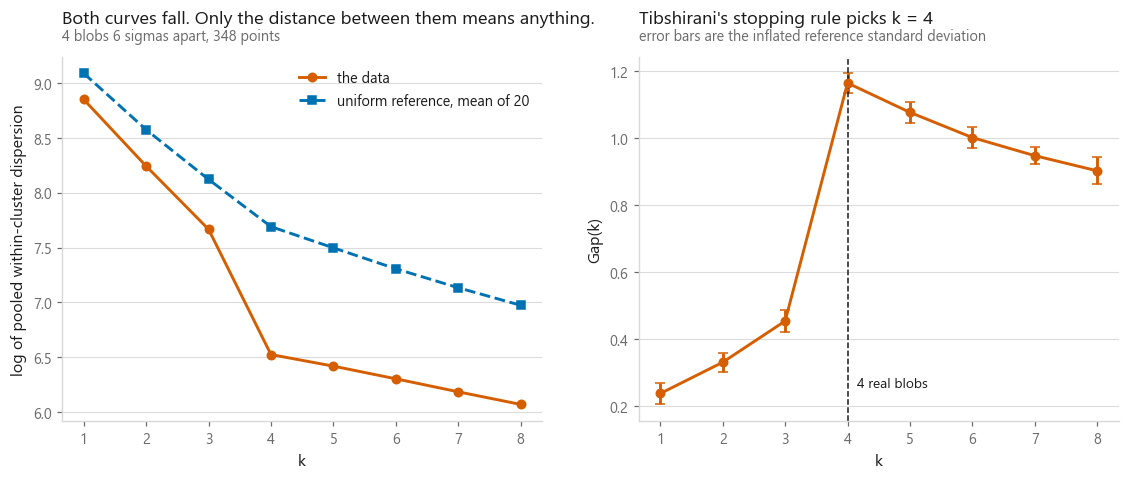

In [3]:
def four_blobs(separation, n_noise_dims=0, n=350, seed=SEED):
    """Four blobs at the corners of a square, optionally buried in noise columns.

    `separation` is in units of the within-cluster standard deviation, which is
    fixed at 1, so the number is directly readable as "how far apart in sigmas".
    Noise columns carry no cluster information at all.
    """
    rng = np.random.default_rng(seed)
    centres = np.array([[0.0, 0.0], [separation, 0.0],
                        [0.0, separation], [separation, separation]])
    per = n // 4
    points = np.vstack([rng.normal(c, 1.0, size=(per, 2)) for c in centres])
    if n_noise_dims:
        points = np.hstack([points, rng.normal(0.0, 1.0, size=(len(points), n_noise_dims))])
    return points


K_RANGE = list(range(1, 9))
TRUE_K = 4
DEMO_SEP = 6.0
N_REFERENCE = 20
demo = four_blobs(separation=DEMO_SEP, seed=SEED)

gap, s_k, log_w = gap_statistic(demo, K_RANGE, n_reference=N_REFERENCE, seed=SEED)
gap_k = gap_choose_k(K_RANGE, gap, s_k)
log_w_ref_mean = gap + log_w

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))

axes[0].plot(K_RANGE, log_w, marker=style.MARKERS[0], ls="-", color=style.HIGHLIGHT,
             label="the data")
axes[0].plot(K_RANGE, log_w_ref_mean, marker=style.MARKERS[1], ls="--",
             color=style.PALETTE[0], label=f"uniform reference, mean of {N_REFERENCE}")
axes[0].set_xlabel("k")
axes[0].set_ylabel("log of pooled within-cluster dispersion")
axes[0].legend(loc="upper right")
style.title(axes[0], "Both curves fall. Only the distance between them means anything.",
            f"{TRUE_K} blobs {DEMO_SEP:.0f} sigmas apart, {len(demo)} points")

axes[1].errorbar(K_RANGE, gap, yerr=s_k, marker=style.MARKERS[0], ls="-",
                 color=style.HIGHLIGHT, capsize=3)
axes[1].axvline(TRUE_K, color=style.INK, ls="--", lw=1)
axes[1].annotate(f"{TRUE_K} real blobs", xy=(TRUE_K, min(gap)), xytext=(6, 4),
                 textcoords="offset points", fontsize=9, color=style.INK)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Gap(k)")
style.title(axes[1], f"Tibshirani's stopping rule picks k = {gap_k}",
            "error bars are the inflated reference standard deviation")

style.save(fig, FIG / "fig-01-gap-mechanics.png")

print(f"true k          : {TRUE_K}")
print(f"gap statistic   : {gap_k}")
print("\nk   log W(data)  log W(ref)   Gap      s_k")
for i, k in enumerate(K_RANGE):
    print(f"{k:<3} {log_w[i]:>11.3f} {log_w_ref_mean[i]:>11.3f} "
          f"{gap[i]:>8.3f} {s_k[i]:>8.3f}")

The left panel is the argument in one picture. Both curves fall with `k`, so the
fall on its own tells you nothing. What the gap statistic measures is the
vertical distance between them, and that distance is only large where the data
has structure the uniform reference does not.

## 4. In practice: how often does each one get it right?

Three criteria on one dataset, side by side, before the bulk run.

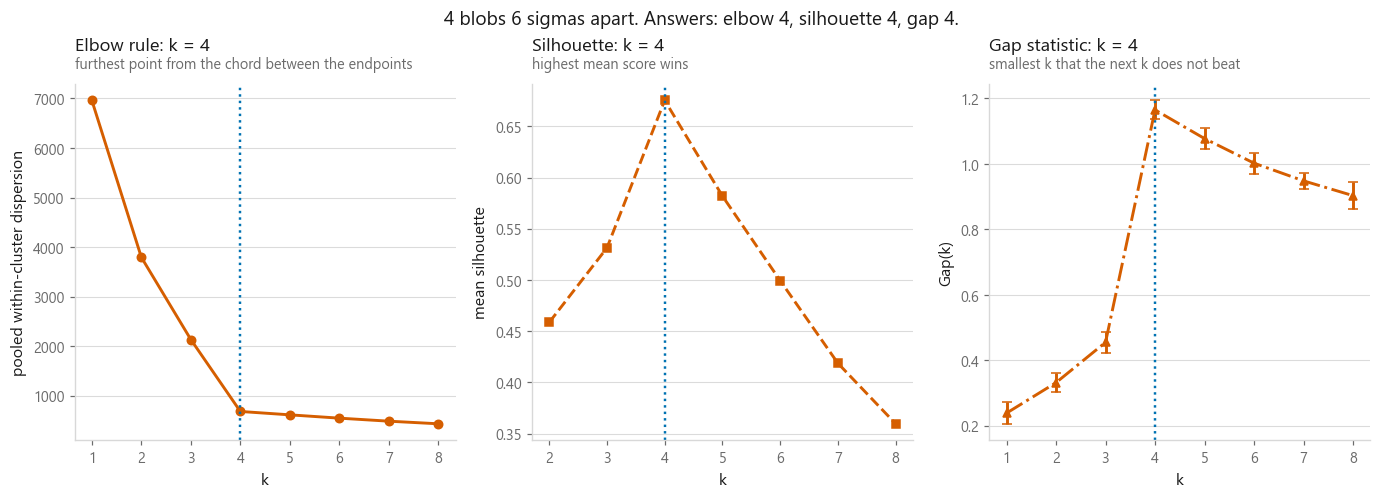

In [4]:
sil_range = list(range(2, 9))
dispersions = [within_dispersion(demo, k) for k in K_RANGE]
elbow_k = elbow_choose_k(K_RANGE, dispersions)
sil_k, sil_scores = silhouette_choose_k(demo, sil_range)

fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.2))

axes[0].plot(K_RANGE, dispersions, marker=style.MARKERS[0], ls="-", color=style.HIGHLIGHT)
axes[0].axvline(elbow_k, color=style.PALETTE[0], ls=":", lw=1.6)
axes[0].set_xlabel("k")
axes[0].set_ylabel("pooled within-cluster dispersion")
style.title(axes[0], f"Elbow rule: k = {elbow_k}",
            "furthest point from the chord between the endpoints")

axes[1].plot(sil_range, sil_scores, marker=style.MARKERS[1], ls="--", color=style.HIGHLIGHT)
axes[1].axvline(sil_k, color=style.PALETTE[0], ls=":", lw=1.6)
axes[1].set_xlabel("k")
axes[1].set_ylabel("mean silhouette")
style.title(axes[1], f"Silhouette: k = {sil_k}", "highest mean score wins")

axes[2].errorbar(K_RANGE, gap, yerr=s_k, marker=style.MARKERS[2], ls="-.",
                 color=style.HIGHLIGHT, capsize=3)
axes[2].axvline(gap_k, color=style.PALETTE[0], ls=":", lw=1.6)
axes[2].set_xlabel("k")
axes[2].set_ylabel("Gap(k)")
style.title(axes[2], f"Gap statistic: k = {gap_k}", "smallest k that the next k does not beat")

fig.suptitle(f"{TRUE_K} blobs {DEMO_SEP:.0f} sigmas apart. Answers: elbow {elbow_k}, "
             f"silhouette {sil_k}, gap {gap_k}.",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-three-criteria.png")

### The bulk run

One dataset proves nothing. Two sweeps, each repeated with different seeds, each
scored on whether the criterion returned the number the data was built with.

The first sweep moves the blobs apart, from heavily overlapping to obviously
distinct. The second keeps the separation fixed and adds columns of pure noise,
which is what real data looks like: the cluster structure lives in a few features
and the rest are along for the ride.

In [5]:
def all_three(X, k_max=8, n_reference=8, seed=SEED):
    """Every criterion's choice of k for one dataset."""
    ks = list(range(1, k_max + 1))
    dispersion = [within_dispersion(X, k, seed) for k in ks]
    elbow = elbow_choose_k(ks, dispersion)
    sil, _ = silhouette_choose_k(X, list(range(2, k_max + 1)), seed)
    g, s, _ = gap_statistic(X, ks, n_reference=n_reference, seed=seed)
    return {"elbow": elbow, "silhouette": sil, "gap": gap_choose_k(ks, g, s)}


N_REPEATS = 6
FIXED_SEP = 5.0
separations = [2.0, 3.0, 4.0, 5.0, 6.0, 8.0]
noise_dims = [0, 2, 5, 10, 20, 40]

start = time.perf_counter()
rows = []
for sep in separations:
    for r in range(N_REPEATS):
        X = four_blobs(sep, 0, seed=100 + r)
        rows.append({"sweep": "separation", "setting": sep, **all_three(X, seed=100 + r)})
for nd in noise_dims:
    for r in range(N_REPEATS):
        X = four_blobs(FIXED_SEP, nd, seed=200 + r)
        rows.append({"sweep": "noise columns", "setting": nd, **all_three(X, seed=200 + r)})
sweep = pd.DataFrame(rows)
sweep_seconds = time.perf_counter() - start

for method in ["elbow", "silhouette", "gap"]:
    sweep[method] = sweep[method] == TRUE_K

recovery = sweep.groupby(["sweep", "setting"])[["elbow", "silhouette", "gap"]].mean()
print(f"{len(sweep)} datasets, {sweep_seconds:.0f} s\n")
print("share of runs recovering the true k = 4")
print(recovery.round(3).to_string())
overall = sweep[["elbow", "silhouette", "gap"]].mean()
print("\noverall, across every setting:")
print(overall.round(3).to_string())
# Each of those is a proportion over the same set of datasets, so it carries its
# own standard error. Print it, or the temptation is to crown whichever number is
# highest and move on.
n_runs = len(sweep)
se_recovery = float(np.sqrt(0.25 / n_runs))
print(f"\neach share is over {n_runs} datasets, standard error at worst {se_recovery:.3f}")
print(f"spread between the best and worst criterion overall: "
      f"{overall.max() - overall.min():.3f}")

72 datasets, 72 s

share of runs recovering the true k = 4
                       elbow  silhouette    gap
sweep         setting                          
noise columns 0.0        1.0       1.000  0.500
              2.0        1.0       1.000  1.000
              5.0        1.0       1.000  1.000
              10.0       1.0       0.833  1.000
              20.0       1.0       0.167  1.000
              40.0       1.0       0.000  1.000
separation    2.0        0.0       0.000  0.000
              3.0        1.0       1.000  0.000
              4.0        1.0       1.000  0.000
              5.0        1.0       1.000  0.500
              6.0        1.0       1.000  0.833
              8.0        1.0       1.000  1.000

overall, across every setting:
elbow         0.917
silhouette    0.750
gap           0.653

each share is over 72 datasets, standard error at worst 0.059
spread between the best and worst criterion overall: 0.264


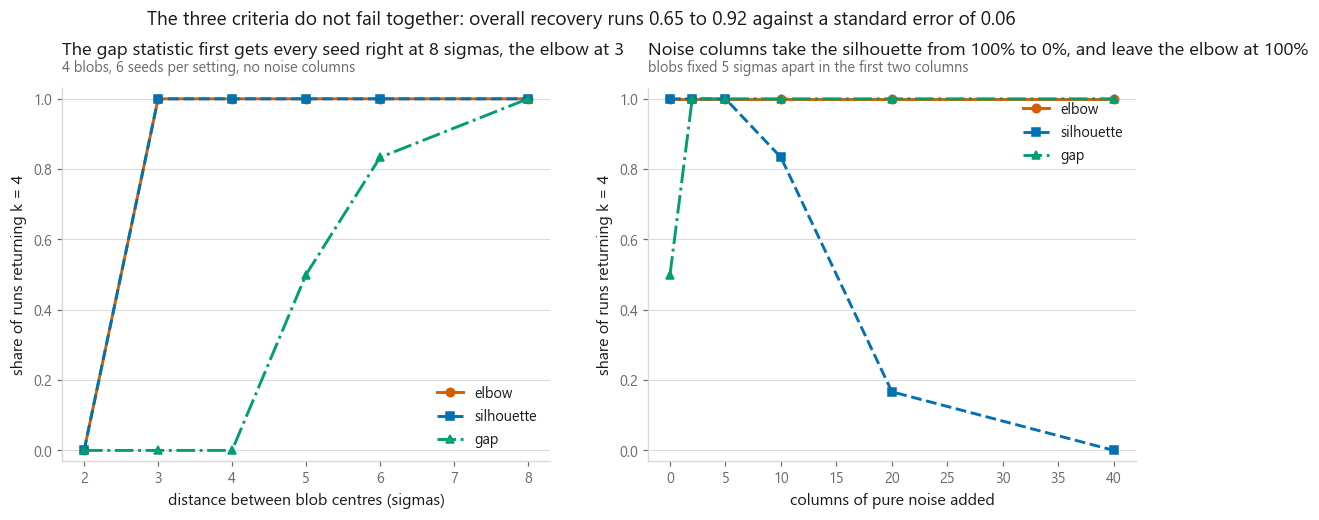

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
styles = [(style.HIGHLIGHT, style.MARKERS[0], "-"),
          (style.PALETTE[0], style.MARKERS[1], "--"),
          (style.PALETTE[2], style.MARKERS[2], "-.")]

for ax, sweep_name, xlabel in [(axes[0], "separation", "distance between blob centres (sigmas)"),
                               (axes[1], "noise columns", "columns of pure noise added")]:
    part = recovery.loc[sweep_name]
    for (colour, marker, dash), method in zip(styles, ["elbow", "silhouette", "gap"]):
        ax.plot(part.index, part[method], marker=marker, ls=dash, color=colour, label=method)
    ax.set_ylim(-0.03, 1.03)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("share of runs returning k = 4")
    ax.legend(loc="lower right" if sweep_name == "separation" else "upper right")

sep_part = recovery.loc["separation"]
noise_part = recovery.loc["noise columns"]

# Averaging the three lines together would hide the whole result, because they do
# not move together. Every number in these titles is per criterion.
def first_perfect(column):
    """Smallest setting at which this criterion recovered k on every seed."""
    perfect = column.index[column.to_numpy() >= 1.0]
    return f"{perfect[0]:g}" if len(perfect) else "never"


style.title(axes[0],
            f"The gap statistic first gets every seed right at "
            f"{first_perfect(sep_part['gap'])} sigmas, the elbow at "
            f"{first_perfect(sep_part['elbow'])}",
            f"{TRUE_K} blobs, {N_REPEATS} seeds per setting, no noise columns")
style.title(axes[1],
            f"Noise columns take the silhouette from {noise_part['silhouette'].iloc[0]:.0%} "
            f"to {noise_part['silhouette'].iloc[-1]:.0%}, and leave the elbow at "
            f"{noise_part['elbow'].iloc[-1]:.0%}",
            f"blobs fixed {FIXED_SEP:.0f} sigmas apart in the first two columns")
fig.suptitle(f"The three criteria do not fail together: overall recovery runs "
             f"{overall.min():.2f} to {overall.max():.2f} against a standard error "
             f"of {se_recovery:.2f}",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-03-recovery.png")

Read the printed table column by column rather than eyeballing the lines, and
resist averaging the three. **The whole result is that they do not move
together**, and a mean across them would delete it.

The left panel is the easy regime and the one every tutorial uses. Once the blobs
are a few sigmas apart the elbow and the silhouette are simply correct, and a
demonstration built here would make either look infallible. The gap statistic is
the slow one: it needs the blobs much further apart before it will commit,
because its stopping rule is deliberately conservative and demands that the next
k fails to beat the current one by more than the reference spread. That
conservatism is the same property that lets it answer 1 in section 5. You are
paying for it here.

The right panel is closer to real data and it is where the three come apart. The
clusters stay exactly as separated as before, in exactly the same two columns, and
every column added is pure noise. Squared Euclidean distance sums over all of
them, so the usual expectation is that everything degrades. Read the printed
columns before believing that.

The silhouette is the one that behaves as expected, and its mechanism is specific
rather than general. A silhouette is a ratio, $(b - a) / \max(a, b)$. Isotropic
noise columns inflate $a$ and $b$ by nearly the same amount, because they add the
same expected distance to a neighbour inside the cluster and to one outside it.
The difference in the numerator stays where it was while the denominator grows, so
every point's silhouette is squeezed toward zero and the curve over k flattens.
The peak of a flat curve is wherever the random wobble happens to be highest. The
silhouette does not degrade gracefully. It stops having a peak worth reading.

The elbow does not care, and the reason is in the rule rather than in the
geometry. Adding isotropic noise raises the pooled dispersion at every k by
roughly the same additive amount, and the chord rule min-max normalises both axes
before measuring distance to the chord. A constant added to every point of the
curve barely moves where the curve bends. Being the least principled criterion of
the three turns out to make it the least fragile.

So the lesson is not the tidy one. Feature selection matters, and which criterion
you were relying on decides how much. Before trusting any of them on wide data,
check whether the criterion is reading a shape or reading a maximum, because the
maxima are the ones that dissolve.

## 5. When they lose: data with no clusters

Now the case the recovery sweep cannot reach, because every dataset in it had
four clusters by construction.

Four structureless datasets and one positive control. If a criterion is worth
anything it must return 1 for the first four and 4 for the last one. Recall from
section 2 that two of the three are not allowed to return 1 at all.

DBSCAN joins the table because [05-04](../04-dbscan-and-hdbscan/) hit this from a
different direction, and a claim repeated across chapters should be re-measured
rather than quoted.

In [7]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

null_rng = np.random.default_rng(SEED)
cases = {
    "uniform square (2 cols)": null_rng.uniform(0, 1, size=(400, 2)),
    "uniform cube (10 cols)": null_rng.uniform(0, 1, size=(400, 10)),
    "one round Gaussian": null_rng.normal(0, 1, size=(400, 2)),
    "one stretched Gaussian": null_rng.normal(0, 1, size=(400, 2)) @ np.array([[4.0, 0.0],
                                                                              [0.0, 0.4]]),
    "four real blobs (control)": four_blobs(DEMO_SEP, 0, n=400, seed=SEED),
}
truth = {"uniform square (2 cols)": 1, "uniform cube (10 cols)": 1, "one round Gaussian": 1,
         "one stretched Gaussian": 1, "four real blobs (control)": 4}

null_rows = []
for name, points in cases.items():
    picks = all_three(points, k_max=8, n_reference=20, seed=SEED)
    scaled = StandardScaler().fit_transform(points)
    db = DBSCAN(eps=0.30, min_samples=8).fit(scaled)   # the settings 05-04 used
    found = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    null_rows.append({"data": name, "true k": truth[name], **picks,
                      "DBSCAN": found, "DBSCAN noise": f"{(db.labels_ == -1).mean():.0%}"})

null_table = pd.DataFrame(null_rows)
print(null_table.to_string(index=False))
print("\n1 means 'this data has no clusters'.")
for method in ["elbow", "silhouette", "gap"]:
    said_one = int((null_table[method].iloc[:4] == 1).sum())
    print(f"  {method:<11} said 1 on {said_one} of the 4 structureless datasets")

                     data  true k  elbow  silhouette  gap  DBSCAN DBSCAN noise
  uniform square (2 cols)       1      4           4    1       5           6%
   uniform cube (10 cols)       1      4           7    1       0         100%
       one round Gaussian       1      3           3    1       1          24%
   one stretched Gaussian       1      3           3    1       3          23%
four real blobs (control)       4      4           4    2       4           4%

1 means 'this data has no clusters'.
  elbow       said 1 on 0 of the 4 structureless datasets
  silhouette  said 1 on 0 of the 4 structureless datasets
  gap         said 1 on 4 of the 4 structureless datasets


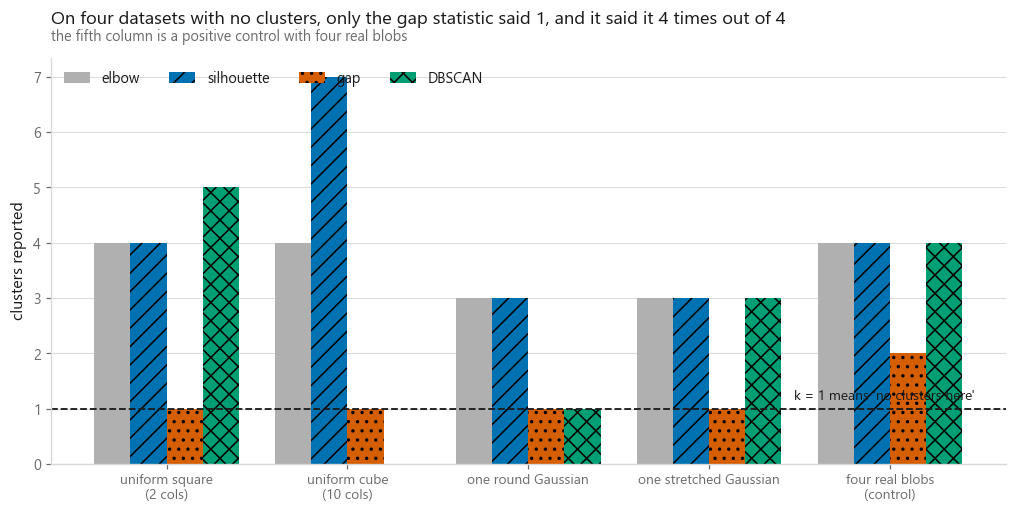

In [8]:
methods = ["elbow", "silhouette", "gap", "DBSCAN"]
hatches = ["", "//", "..", "xx"]
colours = [style.NEUTRAL, style.PALETTE[0], style.HIGHLIGHT, style.PALETTE[2]]
positions = np.arange(len(null_table))
width = 0.2

fig, ax = plt.subplots(figsize=(11.2, 4.8))
for j, (method, hatch, colour) in enumerate(zip(methods, hatches, colours)):
    ax.bar(positions + (j - 1.5) * width, null_table[method], width=width,
           color=colour, hatch=hatch, label=method)
ax.axhline(1, color=style.INK, ls="--", lw=1.2)
ax.annotate("k = 1 means 'no clusters here'", xy=(len(null_table) - 0.5, 1),
            xytext=(-4, 6), textcoords="offset points", ha="right", fontsize=9,
            color=style.INK)
ax.set_xticks(positions, [n.replace(" (", "\n(") for n in null_table["data"]], fontsize=9)
ax.set_ylabel("clusters reported")
ax.legend(loc="upper left", ncol=4)
gap_nulls = int((null_table["gap"].iloc[:4] == 1).sum())
style.title(ax, f"On four datasets with no clusters, only the gap statistic said 1, "
                f"and it said it {gap_nulls} times out of 4",
            "the fifth column is a positive control with four real blobs")
style.save(fig, FIG / "fig-04-null-data.png")

Read the printed table before reading the bars, then read this.

The elbow and the silhouette were never candidates here. Not because they are
badly implemented, but because of section 2: the chord rule cannot select an
endpoint, and the silhouette is undefined at k = 1. **Neither one has the answer
"there are no clusters" in its vocabulary.** Whatever number they returned above,
they were going to return some number, and that is the problem with using them
alone.

The gap statistic can say 1, which is the whole reason it belongs in this
chapter, and the printed count says how often it did. Where it did not, the
reason is in the null rather than in the implementation.

The null it tests is **uniform over the bounding box**. A single Gaussian is not
uniform: it is dense in the middle and empty at the edges, and against a uniform
reference that density contrast is real structure, so a unimodal cloud can
legitimately register as clustered. The stretched Gaussian stresses this harder,
because the bounding box is a wide rectangle while the data fills a thin one, so
most of the reference points land where the data never goes.

So the gap statistic does not test "is there structure". It tests "is there more
structure than a uniform box", and those differ exactly when your data is
unimodal but not uniform. Tibshirani's paper offers a second reference
distribution for this, a uniform box aligned with the principal components, and
it is worth knowing about when the data is strongly anisotropic.

DBSCAN is in the table because [05-04](../04-dbscan-and-hdbscan/) found it
reporting clusters in uniform noise, and the numbers above are that result
recomputed here at the same settings. DBSCAN has a noise label, which k-means
structurally lacks, and having a noise label is still not the same as being able
to say "nothing here".

### Dry Bean, where the answer is known and nobody is told

[05-01](../01-k-means/) already found the silhouette pointing somewhere other than
the true variety count. Now all three criteria get asked, and the agreement with
the true varieties is measured at every k so the cost of a wrong answer is
visible rather than assumed.

In [9]:
from sklearn.metrics import adjusted_rand_score

X_bean, y_bean = datasets.dry_bean()
sub = np.random.default_rng(SEED).choice(len(X_bean), 3000, replace=False)
X_bean_scaled = StandardScaler().fit_transform(X_bean.values[sub])
y_bean_sub = y_bean.values[sub]

bean_ks = list(range(1, 13))
bean_sil_ks = list(range(2, 13))
bean_dispersion = [within_dispersion(X_bean_scaled, k, SEED, n_init=5) for k in bean_ks]
bean_elbow = elbow_choose_k(bean_ks, bean_dispersion)
bean_sil, bean_sil_scores = silhouette_choose_k(X_bean_scaled, bean_sil_ks, SEED, n_init=5)
bean_gap, bean_s, _ = gap_statistic(X_bean_scaled, bean_ks, n_reference=10, seed=SEED, n_init=5)
bean_gap_k = gap_choose_k(bean_ks, bean_gap, bean_s)

bean_ari = [adjusted_rand_score(y_bean_sub,
                                KMeans(n_clusters=k, n_init=5, random_state=SEED)
                                .fit_predict(X_bean_scaled))
            for k in bean_sil_ks]

print(f"{len(X_bean_scaled):,} beans sampled from {len(X_bean):,}, "
      f"{X_bean_scaled.shape[1]} scaled measurements, 7 true varieties\n")
print(f"elbow         : k = {bean_elbow}")
print(f"silhouette    : k = {bean_sil}")
print(f"gap statistic : k = {bean_gap_k}")
hits = [name for name, k in [("elbow", bean_elbow), ("silhouette", bean_sil),
                             ("gap", bean_gap_k)] if k == 7]
print(f"\ncriteria landing on the true k = 7 : {hits if hits else 'none'}")
print(f"\nbest adjusted Rand index {max(bean_ari):.3f} at k = {bean_sil_ks[int(np.argmax(bean_ari))]}")
print(f"adjusted Rand index at k = 7 : {bean_ari[bean_sil_ks.index(7)]:.3f}")

3,000 beans sampled from 13,611, 16 scaled measurements, 7 true varieties

elbow         : k = 4
silhouette    : k = 3
gap statistic : k = 12

criteria landing on the true k = 7 : none

best adjusted Rand index 0.705 at k = 8
adjusted Rand index at k = 7 : 0.679


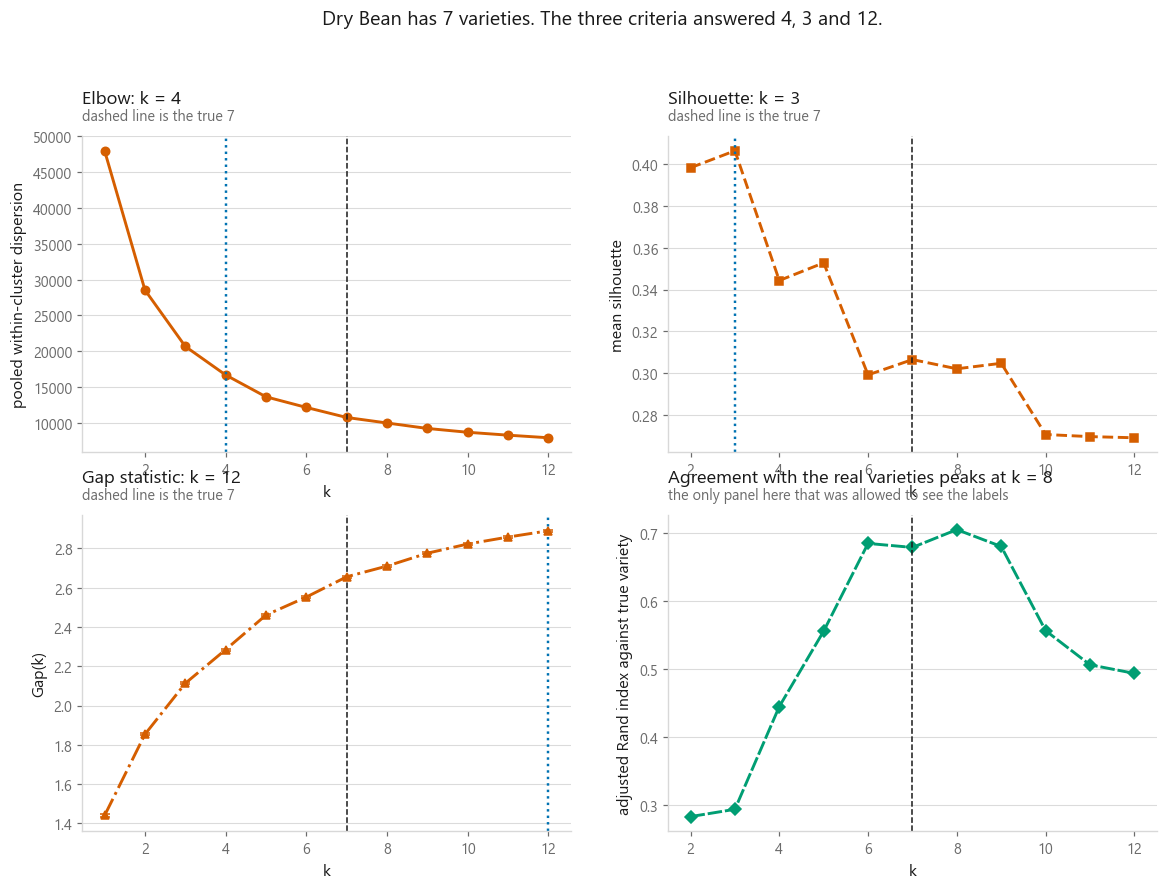

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12.6, 8.2))

axes[0, 0].plot(bean_ks, bean_dispersion, marker=style.MARKERS[0], ls="-", color=style.HIGHLIGHT)
axes[0, 0].axvline(7, color=style.INK, ls="--", lw=1)
axes[0, 0].axvline(bean_elbow, color=style.PALETTE[0], ls=":", lw=1.6)
axes[0, 0].set_xlabel("k"); axes[0, 0].set_ylabel("pooled within-cluster dispersion")
style.title(axes[0, 0], f"Elbow: k = {bean_elbow}", "dashed line is the true 7")

axes[0, 1].plot(bean_sil_ks, bean_sil_scores, marker=style.MARKERS[1], ls="--",
                color=style.HIGHLIGHT)
axes[0, 1].axvline(7, color=style.INK, ls="--", lw=1)
axes[0, 1].axvline(bean_sil, color=style.PALETTE[0], ls=":", lw=1.6)
axes[0, 1].set_xlabel("k"); axes[0, 1].set_ylabel("mean silhouette")
style.title(axes[0, 1], f"Silhouette: k = {bean_sil}", "dashed line is the true 7")

axes[1, 0].errorbar(bean_ks, bean_gap, yerr=bean_s, marker=style.MARKERS[2], ls="-.",
                    color=style.HIGHLIGHT, capsize=3)
axes[1, 0].axvline(7, color=style.INK, ls="--", lw=1)
axes[1, 0].axvline(bean_gap_k, color=style.PALETTE[0], ls=":", lw=1.6)
axes[1, 0].set_xlabel("k"); axes[1, 0].set_ylabel("Gap(k)")
style.title(axes[1, 0], f"Gap statistic: k = {bean_gap_k}", "dashed line is the true 7")

axes[1, 1].plot(bean_sil_ks, bean_ari, marker=style.MARKERS[3], ls=(0, (5, 1)),
                color=style.PALETTE[2])
axes[1, 1].axvline(7, color=style.INK, ls="--", lw=1)
axes[1, 1].set_xlabel("k"); axes[1, 1].set_ylabel("adjusted Rand index against true variety")
style.title(axes[1, 1],
            f"Agreement with the real varieties peaks at "
            f"k = {bean_sil_ks[int(np.argmax(bean_ari))]}",
            "the only panel here that was allowed to see the labels")

fig.suptitle(f"Dry Bean has 7 varieties. The three criteria answered "
             f"{bean_elbow}, {bean_sil} and {bean_gap_k}.",
             x=0.5, y=1.02, fontsize=13, color=style.INK)
style.save(fig, FIG / "fig-05-dry-bean.png")

The bottom-right panel is the one that changes how I read the other three. It is
the adjusted Rand index against the true varieties at every k, and it is the only
panel in this notebook computed with the labels in hand. The print says where it
peaks and what it scores at k = 7.

Two readings, and which one applies depends on where that peak sits.

If the agreement peaks at 7, then the criteria simply got it wrong and the
unsupervised problem is harder than the supervised one, which is the ordinary
case. If it peaks somewhere else, the finding is sharper and more useful: the k
that best reproduces the botanical varieties is not the k that best reproduces
the *geometry* those varieties happen to have, and no criterion reading only the
geometry could possibly have found 7. Two varieties that overlap in shape space
are one cluster however you count, and a third that splits into large and small
specimens is two.

Either way the practical consequence is the same and it is the reason this panel
exists. **A clustering criterion answers a question about geometry, and your
labels answer a question about the world.** Those coincide only when the thing
you named the classes after is the thing the measurements capture. When somebody
asks a clustering to recover a known category, that assumption is the claim being
made, and it is checkable exactly once: here, with the labels in hand, on a
dataset where you have them.

### What I would actually do

The honest summary of everything above is that none of the three is a k detector.
They are three different summaries of a shape, and each is being asked a question
it half answers.

So: run all three, and treat disagreement as the signal it is. Where they agree,
the structure is strong enough that you would probably have seen it in a
[PCA](../../06-dimensionality-reduction/01-principal-component-analysis/) plot
anyway. Where they disagree, the honest report is a range, not a number.

And run the gap statistic even when you already believe there are clusters,
because it is the only one of the three that can come back and tell you there are
not. A criterion that cannot fail is not evidence.

## Cheat sheet

| | |
|---|---|
| **Elbow** | Free, since `inertia_` is already computed. Needs an automated rule to be reproducible, and the usual rule can never return the smallest k in your range |
| **Silhouette** | Has a genuine maximum, and reports per-point scores you can plot. $O(n^2)$ in distance computations, so subsample above a few thousand rows. Undefined at k = 1 |
| **Gap statistic** | The only one here that can answer "no clusters". Costs $B + 1$ clusterings at every k. Not in scikit-learn, so section 3 writes it out |
| **The gap's null** | Uniform over the bounding box. A single Gaussian is not uniform, so a unimodal cloud can still register as structure |
| **All three** | Degrade as you add columns that carry no cluster information, because squared distance sums over every column |
| **Before any of them** | Standardise. And plot the data, in two dimensions, with [PCA](../../06-dimensionality-reduction/01-principal-component-analysis/) |
| **Next** | [Hierarchical clustering](../03-hierarchical-clustering/), which gives every k at once and moves the decision to where you cut the tree |

## What to remember

1. Pooled within-cluster dispersion falls with k on every dataset, structured or
   not, so the fall itself carries no information. Every criterion here is a
   different way of asking whether it fell faster than it should have.
2. The elbow's usual automation cannot return the smallest k in your range, and
   the silhouette is undefined for one cluster. Neither can report "no clusters".
3. The gap statistic compares against a null you can name, which is what makes it
   falsifiable and what makes its failures diagnosable.
4. That null is a uniform box. A single Gaussian is dense in the middle and empty
   at the edges, which a uniform box counts as real structure, so know what the
   gap statistic is comparing against before you trust it on unimodal data.
5. Noise columns did not damage all three equally, and averaging their recovery
   rates would have hidden that completely. The silhouette collapsed, the elbow
   did not move. Report criteria separately.
6. The silhouette collapses because it is a ratio: isotropic noise inflates the
   within and between distances together, the curve over k flattens, and the
   argmax of a flat curve is noise. A criterion built on a maximum dissolves in a
   way a criterion built on a shape does not.
7. The gap statistic's conservatism costs it on easy data and buys it the only
   honest answer on structureless data. That is one property with two prices, not
   a defect.
8. On Dry Bean the true k is 7 and the criteria disagreed with it and with each
   other. Report a range and say which criterion said what.
9. A criterion answers a question about geometry and your labels answer a question
   about the world. Expecting them to agree is a claim about the data, not a
   property of the method.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [05-03 Hierarchical clustering](../03-hierarchical-clustering/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#Clustering` `#KMeans` `#GapStatistic` `#Silhouette`
`#UnsupervisedLearning` `#Python` `#ScikitLearn` `#DataScience` `#MLTutorial`